The "clustering.csv" consists of marks of 1000 students on 10 courses. We will see whether clustering can help identify students with different patterns of achievement across these courses.

**Hierarchical Clustering**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, cophenet

In [2]:
# 1. Read CSV file 
df = pd.read_csv("clustering.csv")

In [3]:
# Preview data: First 5 rows of the dataset 
print(df.head())

# Summary statistics
print(df.describe())


   M1Q1  M1Q2  M1Q3  M1Q4  M1Q5  M2Q1  M2Q2  M2Q3  M2Q4   M2Q5
0  70.1  77.6  75.5  67.0  71.4  81.1  82.9  90.3  73.5   73.4
1  77.6  78.9  70.8  70.0  71.3  63.4  69.8  72.6  69.6   74.9
2  67.6  63.4  68.6  71.1  56.3  68.2  67.6  35.9  65.2   50.5
3  72.4  73.7  69.6  76.7  72.6  67.1  74.4  72.3  74.8   73.4
4  85.2  71.4  75.4  78.9  70.5  85.3  73.7  60.6  67.4  100.0
              M1Q1        M1Q2         M1Q3         M1Q4         M1Q5  \
count  1000.000000  1000.00000  1000.000000  1000.000000  1000.000000   
mean     73.896600    73.17000    74.527600    71.157000    68.609500   
std       7.217133     6.56655     7.913472    11.202951    12.906182   
min      45.700000    48.80000    45.700000    33.800000    20.600000   
25%      69.100000    69.10000    69.400000    64.400000    61.375000   
50%      74.000000    73.50000    75.000000    71.300000    70.550000   
75%      78.225000    77.50000    79.600000    78.900000    77.200000   
max      94.300000    95.60000   100.0

In [4]:
# Use all columns for clustering
X = df.values  

# Standardise data (Optional)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# 2. Pick linkage by CPCC
linkages = ["single", "complete", "average", "ward"]
Y = pdist(X_scaled, metric="euclidean")  # original pairwise distances in scaled space

cpcc_scores = {}
for m in linkages:
    # Note: for 'ward', metric is effectively Euclidean
    Z = linkage(X_scaled, method=m, metric="euclidean")
    coph_corr, _ = cophenet(Z, Y)
    cpcc_scores[m] = coph_corr

print("CPCC by linkage:")
for m, s in cpcc_scores.items():
    print(f"  {m:8s}: {s:.4f}")

CPCC by linkage:
  single  : 0.7651
  complete: 0.4371
  average : 0.7500
  ward    : 0.5494


In [6]:
# pick linkage with high CPCC, together with by domain knowledge
best_linkage = max(cpcc_scores, key=cpcc_scores.get)
print(f"\nBest linkage by CPCC: {best_linkage} (CPCC={cpcc_scores[best_linkage]:.4f})\n")


Best linkage by CPCC: single (CPCC=0.7651)



In [7]:
# pick k (from the silhouette method, together with domain knowledge)
k = 3

In [8]:
# 3. Apply Hierarchical Clusting
# ----------------------------
agg_final = AgglomerativeClustering(n_clusters=k, linkage=best_linkage, metric="euclidean")
df["Cluster"] = agg_final.fit_predict(X_scaled)

print("Cluster counts:")
print(df["Cluster"].value_counts().sort_index(), "\n")

Cluster counts:
Cluster
0    998
1      1
2      1
Name: count, dtype: int64 



Although *single* linkage has the highest CPCC score, the corresponding clustering results with 3 clusters seem not to make much sense, as two clusters have 1 point each. You may wish to try a different linkage and run the hierarchical clustering again.

Cluster centroids (mean per test, original scale):
             M1Q1       M1Q2       M1Q3       M1Q4       M1Q5       M2Q1  \
Cluster                                                                    
0        73.89519  73.153707  74.534469  71.163226  68.635371  74.698697   
1        57.30000  67.000000  46.600000  45.900000  25.800000  66.400000   
2        91.90000  95.600000  95.600000  90.200000  85.600000  76.100000   

              M2Q2       M2Q3      M2Q4       M2Q5  
Cluster                                             
0        71.864729  67.971643  69.59018  66.277956  
1        84.500000  97.900000  95.10000  83.100000  
2        82.000000  96.100000  46.90000  99.500000   



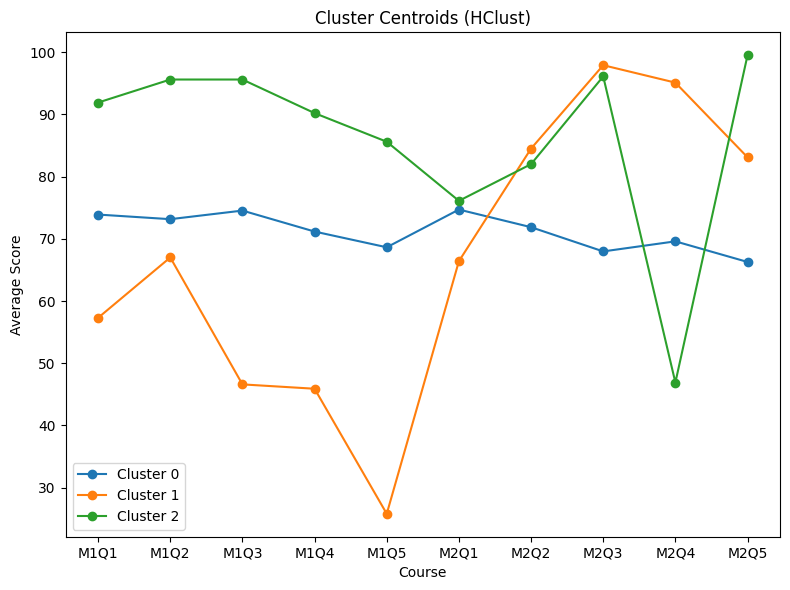

In [9]:
# 4. Calculate and visualise centroids
feature_cols = df.columns.drop("Cluster")
centroid_df = df.groupby("Cluster")[feature_cols].mean().sort_index()

print("Cluster centroids (mean per test, original scale):")
print(centroid_df, "\n")

plt.figure(figsize=(8, 6))
for i, row in centroid_df.iterrows():
    plt.plot(feature_cols, row.values, marker="o", label=f"Cluster {i}")
plt.title("Cluster Centroids (HClust)")
plt.xlabel("Course")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.show()